In [2]:
import numpy as np
import xarray as xr
import xsimlab as xs
import numba #for wrapping the function
import zarr
import matplotlib.pyplot as plt
import scipy as scipy
%load_ext xsimlab.ipython
#plt.style.use('dark_background')
%config InlineBackend.figure_format = 'svg'
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("../../")  # Goes up from Notebook_Examples/Dulleretal2010MODEL_Validation to the overarching folder
sys.path.append(project_root)

# Optional: check that the folder exists
print("Project root added to sys.path:", project_root)
#print("sys.path:", sys.path)

Project root added to sys.path: /Users/amandawild/Desktop/GravelScape


## PART 1) THe Duller et al. (2010) Subsidence Induced Grain Size Model

In [2]:
from GravelScape_ModelSourceCode.Additional import Dulleretal2010_GSSubsidence_Functions


### 1.1) These inputs are for the duller method if you know the inputs for F

In [3]:
#Input an F array and other inputs
#F = np.array([2.5,5,10,100,1000])
F=10
alpha=2.5
phi0=0.75
C1=0.75
CV=0.75
# Downstream profile
DownstreamBasin_m = 200e3
Resolution_m = 1e3
x = np.arange(0,DownstreamBasin_m,Resolution_m)
xstar = x / x[-1]  # shape (201,)

### OR 1.2) These inputs are for the duller method if you know the inputs for initial subsidence S0. 
#It was more designed for the Fastscape model, which is why a time array is needed. Normally time is not needed for Duller et al. (2010) methods. 

In [4]:
#S0=np.array([0.625e-5,1.25e-5,2.5e-5,5e-5,10e-5,100e-5])
#alpha=2.5
#phi0=0.75
#C1=0.75
#CV=0.75
## More inputs to calculate F
#u0=0.001
#wm=1e3
#wb=200e3
#Time grid
#tf = 25e6 # duration of the model run in years
#ts = 2e6 # duration of the first phase of uplift without subsidence
#ntime = 2501#5001 # number of time steps
## Spatial Grid
#xl = 201e3#201e3#250e3 # xl, length of the grid in the x-direction
#yl = 1e3#50e3#100e3#100e3 # yl, length of the mesh in the y-direction #1e3
#Resolution_m = 1e3
#nx = int((xl-Resolution_m)/Resolution_m)#202#251 # number of points in the x-direction
#ny = 2#51#101#101 # number of points in the y-direction #2
#x, y = np.meshgrid(np.linspace(0,xl,nx), np.linspace(0,yl,ny)) # creates an x,y mesh
#sub, F= Dulleretal2010_GSSubsidence_Functions.SubsidenceCurve_Duller_BatchS0(alpha, u0, wm, wb, S0, x, ts, tf, ntime)
#x = np.arange(0,DownstreamBasin_m,Resolution_m)
#xstar = x / x[-1]  # shape (201,)

In [5]:
F

10

### PLot the Grain size using the Duller et al. (2010) Method

In [6]:
#Calculate the Duller et al. 2010 Grain size
if isinstance(F, (float, int)):
        F = np.array([F])
DullerGS_array = Dulleretal2010_GSSubsidence_Functions.dullerGS(
    F[:, np.newaxis],  # shape (8,1) for broadcasting
    alpha, phi0, C1, CV, xstar
)  # shape (8, 201)

# Create xarray DataArray with 1D coordinates
DullerGS = xr.DataArray(
    DullerGS_array,
    dims=['F', 'x'],
    coords={
        'F': ('F', F),       # 1D array, dimension name F
        'x': ('x', x)    # 1D array, dimension name x
    }
)

In [ ]:
#DullerGS.to_dataset(name='grain_size').to_zarr('DullerGS.zarr', mode='w')
DullerGS_loaded = xr.open_zarr('DullerGS.zarr') # This is how the working Duller et al. (2010) model should look like as an example.

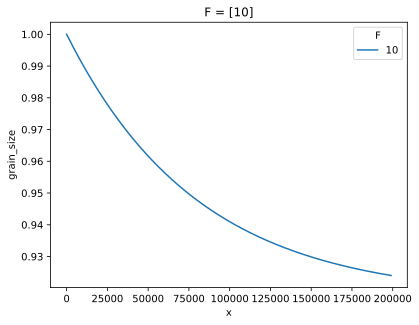

In [35]:
#DullerGS.plot.line(x='x')
DullerGS_loaded.grain_size.plot.line(x='x')

## PART 2) Import FastScape LEM and the GravelScale Model

In [8]:
## Verify that the model is working by constraining it to 1D yl=2e3, ny=2, and resolution=1e3

In [9]:
from GravelScape_ModelSourceCode.Additional import Dulleretal2010_GSSubsidence_Functions #yes you still need this to impose subsidence
from GravelScape_ModelSourceCode.GravelScape import GravelGSN

In [14]:
#Import Fastscape
from ipyfastscape import TopoViz3d
from fastscape.models import sediment_model
from fastscape.processes import FlowAccumulator

from fastscape.processes import (MultipleFlowRouter)
from fastscape.processes import (Bedrock)
from fastscape.processes import (DrainageArea)
#from fastscape.processes import StratigraphicHorizons

#sediment_model = sediment_model.update_processes({'drainage': FlowAccumulator}) # we change the drainage calculator to allow for non uniform rainfall
#sediment_model = sediment_model.update_processes({"flexure": Flexure}).drop_processes('init_topography')
model = sediment_model.update_processes({'flow': MultipleFlowRouter,
                                         'GravelGSN':GravelGSN,
                                         'bedrock':Bedrock,
                                         'drainage': FlowAccumulator
                                         #'strati': StratigraphicHorizons,
                                        # "flexure": Flexure
                                        }).drop_processes('init_topography')

In [11]:
#Spatial and Temporal Variables

xl = 201e3 #201e3 # xl, length of the grid in the x-direction
yl = 1e3 #100e3 # yl, length of the mesh in the y-direction #1e3
nx = int((201)+1) #int((201)+1) # number of points in the x-direction
ny = int((1)+1) #int((100)+1)# number of points in the y-direction #2
x, y = np.meshgrid(np.linspace(0,xl,nx), np.linspace(0,yl,ny)) # creates an x,y mesh

ntime = int((2500)+1)#5001 # number of time steps
tf = 25e6 # duration of the model run in years
ts = 0#2e6 # duration of the first phase of uplift without subsidence

nout = 251 # number of outputs
Tsteady=20e6
#out2=np.linspace(0.75*20e6,20e6,101)

m = 0.4 # area exponent in the SPL
#u0 = 1e-2*relative_fan_size**m # the uplift rate is amplified by the rainfall amplificator factor to the power m
                               # to result in a mountain height that is relatively constant,m regardless of the
                               # value of the rainfall amplification factor
wm = 1e3#(xl/(nx-1))*25 # width of the mountain (in m) #cell size * number of cells
wb = xl - wm # with of the basin (in m)


In [12]:
#Changing Variables
u0=1e-2#1e-2
#F =np.array([2.5,5,10,100,1000]) #7 onwards
F=10
alpha = 2.5 # rate of change of the imposed subsidence rate (the larger the narrower the region of subsidence

In [13]:
if isinstance(F, np.ndarray):
    upliftgrid, F = Dulleretal2010_GSSubsidence_Functions.SubsidenceCurve_Duller_BatchF(
        alpha, u0, wm, wb, F, x, ts, tf, ntime
    )

elif isinstance(F, (float, int)):
    F2 = np.array([F])
    upliftgrid, F2 = Dulleretal2010_GSSubsidence_Functions.SubsidenceCurve_Duller_BatchF(
        alpha, u0, wm, wb, F2, x, ts, tf, ntime
    )
    upliftgrid = upliftgrid.isel(F=0)
    F = F2[0]

else:
    print("error with F file type")

In [14]:
#unless you want the uplift grid to change over time, just simplify to the final timestep
#E.g. if you placed ts greater than 0. 
upliftgrid_1time=upliftgrid.isel(time=-1)

In [15]:
#upliftgrid_1time.mean('y').plot()

In [16]:
#Additionals to make comparable with flexure model
h0 = np.ones([ny,nx]) + np.where(x>wm,1-(x-wm)/(xl-wm), 1) * 250
kf_mountain = 2e-5#xr.DataArray([1e-6,0.25e-5,0.5e-5,0.75e-5,1e-5,0.25e-4,0.5e-4,0.75e-4,1e-4],dims=['Kf'])#5e-5
#kf_basin=2e-5

In [17]:
#upliftgrid

In [18]:
# %create_setup model --default --verbose
import xsimlab as xs

ds_in = xs.create_setup(
    model=model,
    clocks={'time': np.linspace(0,tf,ntime),
           #'out': np.linspace(0,tf,int((tf/((tf-Tsteady)/25))+1)),
           'out2': np.linspace(tf-(5e6),tf,26)}, #THIS ONLY OUTPUTS THE FINAL TIME STEPS THAT SHOULD BE WELL AT STEADY-state
    master_clock = 'time',
    input_vars={
        # nb. of grid nodes in (y, x)
        'grid__shape': [ny,nx],
        # total grid length in (y, x)
        'grid__length': [yl,xl],
        # node status at borders
        'boundary__status': ['core','fixed_value','looped','looped'],
        # uplift rate
        #'uplift__rate': SubsidenceCurve_Duller(alpha, u0Start, wm, wb, F, x, ts, tf, ntime),
        'uplift__rate': upliftgrid_1time,
        # random seed
        #'init_topography__seed': None,
         # initial topography
        "topography__elevation": h0,
        # MFD partioner slope exponent
        'flow__slope_exp': 1.0,
        # drainage area exponent
        'spl__area_exp': m,
        # slope exponent
        'spl__slope_exp': 1,
        # bedrock channel incision coefficient
        'spl__k_coef_bedrock': kf_mountain ,#2e-5,
        # soil (sediment) channel ncision coefficient
        'spl__k_coef_soil': kf_mountain , #1e-5,
        #
        'spl__tol_rel':10e-6,
        #
        'spl__tol_abs':0.0001,
        #
        'spl__max_iter':100,
        # drainage area exponent
        # detached bedrock transport/deposition coefficient
        'spl__g_coef_bedrock': 1,
        # soil (sediment) transport/deposition coefficient
        'spl__g_coef_soil': 1,
        # bedrock diffusivity
        'diffusion__diffusivity_bedrock':0.1 , #0.03,
        # soil (sediment) diffusivity
        'diffusion__diffusivity_soil': 0.1 ,#0.1,
        # The bedrock source D50 grain size
        'GravelGSN__D0': 1,
        # The bedrock source grain size standard deviation
        'GravelGSN__SD0': 0.75,
        # Cv (grain size calculation constant) described in Fedele and Paola (2007) and Duller
        # et al. (2010)
        'GravelGSN__Cv': 0.75,
        # C1 (grain size calculation constant) described in Fedele and Paola (2007) and Duller
        # et al. (2010)
        'GravelGSN__C1': 0.75,
        # Porosity
        'GravelGSN__porosity': 0,
        # runoff
        'drainage__runoff': 1,
        #'strati__freeze_time': np.linspace(0,tf,int((tf/((tf-Tsteady)/25))+1)),

    },
    output_vars={'topography__elevation': 'out2', #multi time step
                'drainage__flowacc': 'out2', #For mobility calculation over time
                #'flow__nb_donors': 'out2', #For longest river calc.
                #'flow__donors': 'out2', #For longest river calc.
                #'flow__nb_receivers':'out2',
                #'flow__receivers':'out2',
                #'flow__stack':'out2',
                #'GravelGSN__D0Source': 'out2', #time step specific GS
                'GravelGSN__DMean': 'out2', #time step specific GS
                'GravelGSN__DTIME': 'out2',
                #'GravelGSN__YStar':'out2',
                #'GravelGSN__EFlux': 'out2',
                'bedrock__elevation': 'out2',
                #'flow__basin':'out2',
                'erosion__rate': 'out2',
                #"strati__elevation": "out"
                }
)

/opt/anaconda3/envs/GravelScape_package2025/lib/python3.10/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'time' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)
/opt/anaconda3/envs/GravelScape_package2025/lib/python3.10/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'out2' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)


In [19]:
import zarr

zgroup = zarr.group("FastScape1d.zarr", overwrite=True)
#zgroup = zarr.group("G1BetaAlpha_Alphadivide10_F2_5F10000_Kf2eN6.zarr", overwrite=True)

In [20]:
# With a single F value

In [21]:
with model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run(store=zgroup)

             0% | initialize 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [37]:
#With multiple F Values

In [38]:
#from dask.distributed import Client
#client = Client(n_workers=3, threads_per_worker=1)

In [39]:
# from dask.diagnostics import ProgressBar
# with model, ProgressBar():
#     ds_out = (ds_in
# #              #.stack(batch=['Precip','F']) # you only need these lines when stacking multiple variables
#               .xsimlab.run(batch_dim='F',check_dims='transpose', parallel=True,scheduler=client,store=zgroup) #scheduler='processes'
# #              #.unstack('batch')
#               )

In [40]:
# With a single F value

In [36]:
GravelScape_F=xr.open_zarr('FastScape1d.zarr')

In [37]:
GrAVelScape_F10=GravelScape_F.GravelGSN__DMean.mean('out2').mean('y')

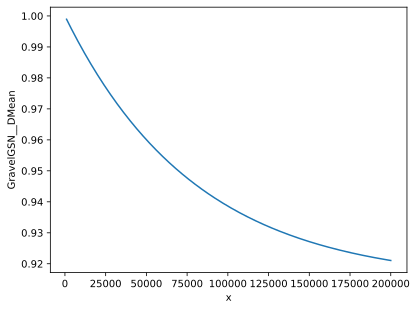

In [38]:
GrAVelScape_F10.plot.line(x='x')

## Part 3) Validation: Duller vs GravelScape

In [ ]:
#Limiting the y-grid in GRavelScpae should cause the solution to match Duller et al. 2010. 

(0.5, 1.0)

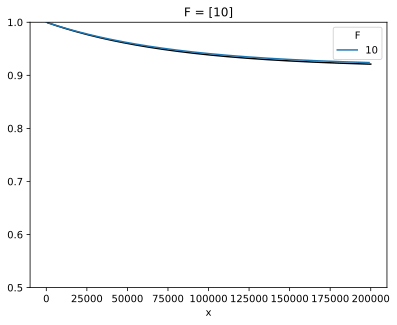

In [89]:
GrAVelScape_F10.plot.line(x='x', color='k')
DullerGS.plot.line(x='x')
plt.ylim(0.5,1)

In [ ]:
#OPtionally Calculate the steady-state channel mobility frequency

In [ ]:
# from GravelScape_ModelSourceCode.Additional import LargestChannelMobility

In [ ]:
# Calculates the frequency of channel movement across the 
#StartTime=0
#EndTime=-1
#ChannelMobility=LargestChannelMobility.MobilityFrequency(GravelScape_F.drainage__flowacc,StartTime,EndTime)